In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('movies.csv')

In [3]:
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9994,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n \n Stars:\nMorgan Taylor Camp...,NaN,NaN,NaN
9995,Arcane,(2021– ),"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN
9996,Heart of Invictus,(2022– ),"\nDocumentary, Sport",NaN,\nAdd a Plot\n,\n Director:\nOrlando von Einsiedel\n| \n ...,NaN,NaN,NaN
9997,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n Director:\nJovanka Vuckovic\n| \n Sta...,NaN,NaN,NaN


In [4]:
df.tail()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
9994,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n \n Stars:\nMorgan Taylor Camp...,NaN,NaN,NaN
9995,Arcane,(2021– ),"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN
9996,Heart of Invictus,(2022– ),"\nDocumentary, Sport",NaN,\nAdd a Plot\n,\n Director:\nOrlando von Einsiedel\n| \n ...,NaN,NaN,NaN
9997,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n Director:\nJovanka Vuckovic\n| \n Sta...,NaN,NaN,NaN
9998,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n Director:\nJovanka Vuckovic\n| \n Sta...,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9355 non-null   object 
 2   GENRE     9919 non-null   object 
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     8179 non-null   object 
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    object 
dtypes: float64(2), object(7)
memory usage: 703.2+ KB


In [6]:
df.isnull().sum()

MOVIES         0
YEAR         644
GENRE         80
RATING      1820
ONE-LINE       0
STARS          0
VOTES       1820
RunTime     2958
Gross       9539
dtype: int64

In [7]:
#fill missing values
df['RATING'] = df['RATING'].fillna(df.groupby('YEAR')['RATING'].transform('mean'))
df['YEAR'] =  df['YEAR'].fillna('unknown')
df['GENRE'] = df['GENRE'].fillna('unknown')
df['RunTime'] = df['RunTime'].fillna(df['RunTime'].median())
df['Gross'] = df['Gross'].fillna(0)
df['VOTES'] = df['VOTES'].str.replace(',', '')
df['VOTES'] = df['VOTES'].fillna(0)


In [8]:
#removing unnecessary values
df['GENRE'] = df['GENRE'].str.replace('\n', '')
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\n', '')
df['STARS'] = df['STARS'].str.replace('\n','')
df['STARS'] = df['STARS'].str.replace('|','')

In [9]:
#remove zeroes(6.100000 -> 6.1)
df['RATING'] = df['RATING'].round(1)

In [10]:
df['YEAR'] = df['YEAR'].str.replace('(', '', regex=False).str.replace(')', '', regex=False)
df['YEAR'] = df['YEAR'].str.strip()

In [11]:
df['RATING'] = df['RATING'].fillna(df['RATING'].mean())

In [12]:
df.isnull().sum()

MOVIES      0
YEAR        0
GENRE       0
RATING      0
ONE-LINE    0
STARS       0
VOTES       0
RunTime     0
Gross       0
dtype: int64

In [13]:
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,2021,"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced in...,Director:Peter Thorwarth Stars:Peri Ba...,21062,121.0,0
1,Masters of the Universe: Revelation,2021–,"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may b...,"Stars:Chris Wood, Sarah Michel...",17870,25.0,0
2,The Walking Dead,2010–2022,"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a com...,"Stars:Andrew Lincoln, Norman R...",885805,44.0,0
3,Rick and Morty,2013–,"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits o...,"Stars:Justin Roiland, Chris Pa...",414849,23.0,0
4,Army of Thieves,2021,"Action, Crime, Horror",6.7,"A prequel, set before the events of Army of th...",Director:Matthias Schweighöfer Stars:M...,0,60.0,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9999 non-null   object 
 2   GENRE     9999 non-null   object 
 3   RATING    9999 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     9999 non-null   object 
 7   RunTime   9999 non-null   float64
 8   Gross     9999 non-null   object 
dtypes: float64(2), object(7)
memory usage: 703.2+ KB


In [15]:
# change wrong datatypes
df['RunTime'] = df['RunTime'].astype(int)

In [16]:
df['VOTES'] = pd.to_numeric(df['VOTES'])
df['YEAR'] = df['YEAR'].astype(str).str.extract(r'(\d{4})')
df['YEAR'] = df['YEAR'].fillna(0)
df['YEAR'] = df['YEAR'].astype(int)
df['YEAR'] = pd.to_numeric(df['YEAR'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9999 non-null   int64  
 2   GENRE     9999 non-null   object 
 3   RATING    9999 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     9999 non-null   int64  
 7   RunTime   9999 non-null   int64  
 8   Gross     9999 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.2+ KB


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9999 non-null   int64  
 2   GENRE     9999 non-null   object 
 3   RATING    9999 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     9999 non-null   int64  
 7   RunTime   9999 non-null   int64  
 8   Gross     9999 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.2+ KB


In [19]:
#top 5 highest grossing movies
df['Gross'] = df['Gross'].astype(str).str.replace('$', '', regex=False).str.replace('M', '', regex=False)
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')
df['Gross'] = (df['Gross'] * 1000000).fillna(0).astype(int)

In [29]:
#Task:1 Find out which movies or shows are highly rated but didn't get much attention
df[(df['RATING']>8.5) & (df['VOTES']<1000)]

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
1681,Kotaro Lives Alone,2021,Drama,9.2,Shin Karino is an unpopular manga artist who s...,"Stars:Natsuki Deguchi, Eito Ka...",62,60,0
1731,Hey Duggee,2014,"Animation, Family",8.9,"Duggee looks after the Squirrels, who earn dif...","Stars:Alexander Armstrong, Jas...",881,7,0
2214,Fake or Fortune?,2010,Documentary,8.6,Journalist Fiona Bruce teams up with art exper...,"Stars:Fiona Bruce, Philip Moul...",504,63,0
2418,Yungnyong-i Nareusya,2015,"Drama, History",8.9,Story of the the foundation of the Joseon Dyna...,"Stars:Yoo Ah-in, Yo-Han Byun, ...",803,60,0
2680,Love and Redemption,2020,"Action, Drama, Fantasy",8.6,"Because of an intricate plot, Zhu Xuan Ji of X...","Stars:Wang Bin, Yu Bin, Zhou Y...",356,60,0
...,...,...,...,...,...,...,...,...,...
9726,Centaurworld,2021,"Animation, Adventure, Comedy",8.9,The herd makes it to the Rift and reminisces a...,"Stars:Kimiko Glenn, Megan Hilt...",10,26,0
9727,Centaurworld,2021,"Animation, Adventure, Comedy",8.6,Horse hopes to find the final shaman in Merfol...,"Stars:Kimiko Glenn, Megan Hilt...",8,27,0
9728,Centaurworld,2021,"Animation, Adventure, Comedy",8.8,Horse and Rider face a frightening enemy. Back...,"Stars:Kimiko Glenn, Megan Hilt...",10,27,0
9833,Never Have I Ever,2020,Comedy,8.7,A disastrous snooping incident compels Devi an...,Director:Claire Scanlon Stars:Maitreyi...,368,60,0


In [28]:
#Task:2 top 5 highest grossing movies
df.sort_values(by='Gross', ascending=False).head(5)

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
329,Beauty and the Beast,2017,"Family, Fantasy, Musical",7.1,A selfish Prince is cursed to become a monster...,Director:Bill Condon Stars:Emma Watson...,284484,129,504010000
578,Finding Dory,2016,"Animation, Adventure, Comedy",7.3,Friendly but forgetful blue tang Dory begins a...,"Directors:Andrew Stanton, Angus MacLane ...",250953,97,486300000
226,Captain America: Civil War,2016,"Action, Adventure, Sci-Fi",7.8,Political involvement in the Avengers' affairs...,"Directors:Anthony Russo, Joe Russo Sta...",697750,147,408080000
144,Jumanji: Welcome to the Jungle,2017,"Action, Adventure, Comedy",6.9,Four teenagers are sucked into a magical video...,Director:Jake Kasdan Stars:Dwayne John...,337900,119,404520000
196,Spider-Man,2002,"Action, Adventure, Sci-Fi",7.3,"When bitten by a genetically modified spider, ...",Director:Sam Raimi Stars:Tobey Maguire...,709684,121,403710000


In [27]:
# Task 3: Splitting and counting each movie genree
exploded_genres = df['GENRE'].str.split(', ').explode()
exploded_genres.value_counts()

GENRE
Drama                      2477
Action                     2188
Drama                      1848
Animation                  1652
Comedy                     1442
Comedy                     1390
Crime                      1241
Adventure                   963
Thriller                    903
Adventure                   829
Romance                     823
Documentary                 724
Mystery                     633
Documentary                 500
Family                      358
Fantasy                     339
Crime                       325
Reality-TV                  320
Horror                      301
History                     278
Biography                   268
Sci-Fi                      255
Horror                      252
Short                       249
Mystery                     247
Fantasy                     233
Sport                       191
Music                       156
Family                       98
History                      94
Game-Show                    87
Ta

Text(0, 0.5, 'Average Rating')

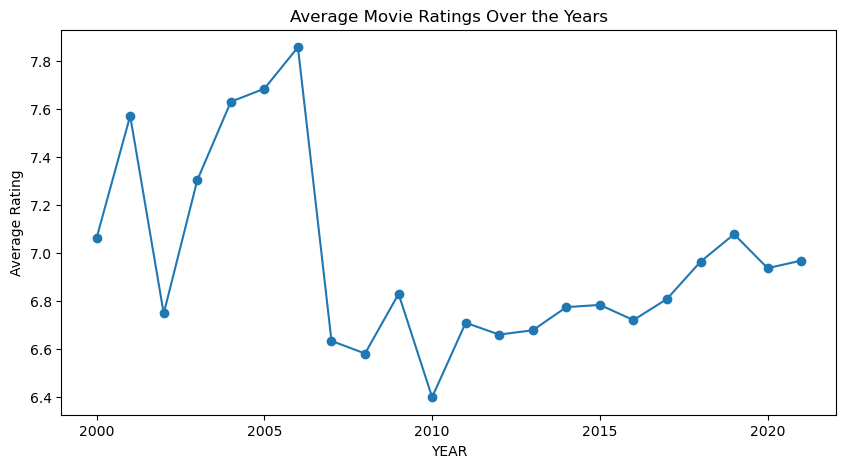

In [30]:
# Task:4 Plotting average movie ratings from 2000 to 2021 over time
filtered_df = df[(df['YEAR'] >= 2000) & (df['YEAR'] <= 2021)]
yearly_rating = filtered_df.groupby('YEAR')['RATING'].mean()
yearly_rating.plot(kind='line', marker='o', figsize=(10, 5))
plt.title("Average Movie Ratings Over the Years")
plt.xlabel("YEAR")
plt.ylabel("Average Rating")